# Sample Grid Generation inside a Cube


Mesh generation using diff point distribution.

In [1]:
# General and plotting
import numpy as np
import subprocess
from pathlib import Path

# import matplotlib.pyplot as plt
# from matplotlib.collections import PatchCollection
# import matplotlib.tri as tri

# Random sampling and Poisson disk sampling
from scipy.stats import qmc
from scipy.spatial import Delaunay

# semiuniform sampling
import pyvista as pv
import tetgen
import meshio
import os

#Uniform sampling
#import meshzoo

# Visualization 
def plot_pyvista(nodes, simplices):
    buf = np.empty((len(simplices), 1), pv.ID_TYPE)
    buf[:] = 4
    elements = np.hstack((buf, simplices))
    elements = elements.flatten()
    cell_type = np.empty(len(simplices), dtype='uint8')
    cell_type[:] = 10

    grid = pv.UnstructuredGrid(elements, cell_type, nodes)
    #grid = tgen.grid

    # get cell centroid
    
    #esta linea es maldita
    #cambia la dimension de los elementos de 1d a 2d n,5.
    # los copia al arreglo cells y le saca primera columna que corresponde al número de vértices
    cells = grid.cells.reshape(-1, 5)[:, 1:]
    #esta wea dado los indices de los vértices de cada celda,
    #obtiene las coordenadas de los vértices y calcula su promedio
    cell_center = grid.points[cells].mean(1)

    # extract cells below the 0 xy plane
    mask = cell_center[:, 2] < 0.5
    cell_ind = mask.nonzero()[0]
    subgrid = grid.extract_cells(cell_ind)
    # advanced plotting
    plotter = pv.Plotter(notebook=True)
    plotter.background_color = 'white'
    plotter.add_mesh(subgrid, 'lightgrey', lighting=True, show_edges=True)
    plotter.add_mesh(pv.Cube(center=(0.5, 0.5, 0.5)), 'r', 'wireframe')
    #plotter.add_legend([[' Input Mesh ', 'r'], [' Tessellated Mesh ', 'black']])
    plotter.show(jupyter_backend='static')

#Move a point to the boundary of the box if the distante to the boundary is less than tolerance
def move_point(max_number, xPoint , yPoint, zPoint, tolerance):
    r =  np.random.uniform(0, 1)
    n = max_number
    # A esta wea la faltan dos casos,pero no sé me ocurren como hacerlo ahora
    if r <= 0.5:
        #if the x coord is near the extreme x coord
        if xPoint >= max_number*(1.0-tolerance): 
            xPoint = n
        #if the y coord is near the extreme y coord
        if yPoint >= max_number*(1.0-tolerance): 
            yPoint = n
        #if the z coord is near the extreme z coord
        if zPoint >= max_number*(1.0-tolerance):
            zPoint = n
        #if the x coord is near the 0-x coord
        if xPoint <= max_number*tolerance: 
            xPoint = 0
        #if the y coord is near the 0-y coord
        if yPoint <= max_number*tolerance: 
            yPoint = 0
        #if the z coord is near the 0-z coord
        if zPoint <= max_number*tolerance:
            zPoint = 0
    else:
        #if the x coord is near the 0-x coord
        if xPoint <= max_number*tolerance: 
            xPoint = 0            
        #if the y coord is near the 0-y coord
        if yPoint <= max_number*tolerance: 
            yPoint = 0
        #if the z coord is near the 0-z coord  
        if zPoint <= max_number*tolerance:
            zPoint = 0
        #if the x coord is near the extreme x coord
        if xPoint >= max_number*(1.0-tolerance): 
            xPoint = n
        #if the y coord is near the extreme y coord
        if yPoint >= max_number*(1.0-tolerance): 
            yPoint = n
        #if the z coord is near the extreme z coord
        if zPoint >= max_number*(1.0-tolerance):
            zPoint = n
        

    #print("returning", xPoint, yPoint)
    return (xPoint, yPoint, zPoint)

def add_box(arr, tolerance):
    box = [[0, 0, 0], [0, 0, 1], [0, 1, 0], [0, 1, 1], [1, 0, 0], [1, 0, 1], [1, 1, 0], [1, 1, 1]]
    arr = np.append(arr, box, axis=0)
    arr = np.unique(arr, axis=0)
    #maxNumber = max(max(arr[:,0]), max(arr[:,1]), max(arr[:,2]))
    for i in range(0, len(arr)):
        new_p = move_point(1, arr[i,0], arr[i,1], arr[i,2], tolerance)
        arr[i,0] = new_p[0]
        arr[i,1] = new_p[1]
        arr[i,2] = new_p[2]
    return arr

### Point configuration parameters:

In [2]:
# tolerance : maximum distance from the boundary
# numVertices : number of random points to generate
# radius : minimum approximate distance between points
# areaMax : maximum area of the triangles in the Delaunay triangulation (TetGen restriction)
# lnspace : number of points in the uniform grid along each axis

# 1000

tolerance = 0.1 # max distance from the boundary
numVertices = 1000 #Random points
radius = 0.084 #1034
areaMax = "0.00038" #996
lnspace = 10 # Uniform sqrt(500)

# Uncomment below for other configurations:

# 500
# tolerance = 0.1 # max distance from the boundary
# numVertices = 500 #Random points
# radius = 0.105 #Poisson
# areaMax = "0.0008" #Semiuniform
# lnspace = 8 # Uniform sqrt(500)

# 5000
#tolerance = 0.05 # max distance from the boundary
#numVertices = 5000 #Random points
#radius= 0.049 # 5001
#areaMax = "0.0000695" # 5030
#lnspace = 17 # 4913

# 10000
#tolerance = 0.05 # max distance from the boundary
#numVertices = 10000 #Random points
#radius= 0.038 # 10175
#areaMax = "0.000033" # 10134
#lnspace = 22 # 10648

# 50000
# tolerance = 0.02 # max distance from the boundary
# numVertices = 50000 #Random points
# radius= 0.0225 #50192
# areaMax = "0.000006279" # 50027
# lnspace = 37 # 10648

Define test parameters for the point distribution inside a cube.

In [3]:
# tolerance : maximum distance from the boundary
# numVertices : number of random points to generate
# radius : minimum approximate distance between points
# areaMax : maximum area of the triangles in the Delaunay triangulation (TetGen restriction)
# lnspace : number of points in the uniform grid along each axis

# Parámetros para pruebas de PolyllaFace con distribución uniforme
#
# En una retícula uniforme:
#   numVertices = lnspace ** 3
#   radius      = distancia entre puntos consecutivos
#   areaMax     = área máxima aproximada de una cara triangular
#
# Número de cubos:
#   (lnspace - 1) ** 3

# 1 cubo
# tolerance = 0.0
# numVertices = 8
# radius = 1.0
# areaMax = "0.5"
# lnspace = 2

# 8 cubos
# tolerance = 0.0
# numVertices = 27
# radius = 0.5
# areaMax = "0.125"
# lnspace = 3

# 27 cubos
# tolerance = 0.0
# numVertices = 64
# radius = 0.3333333333
# areaMax = "0.0555555556"
# lnspace = 4

# 64 cubos
# tolerance = 0.0
# numVertices = 125
# radius = 0.25
# areaMax = "0.03125"
# lnspace = 5

# 125 cubos
# tolerance = 0.0
# numVertices = 216
# radius = 0.2
# areaMax = "0.02"
# lnspace = 6

# 216 cubos
# tolerance = 0.0
# numVertices = 343
# radius = 0.1666666667
# areaMax = "0.0138888889"
# lnspace = 7

# 343 cubos
# tolerance = 0.0
# numVertices = 512
# radius = 0.1428571429
# areaMax = "0.0102040816"
# lnspace = 8

# 512 cubos
# tolerance = 0.0
# numVertices = 729
# radius = 0.125
# areaMax = "0.0078125"
# lnspace = 9

# 729 cubos
# tolerance = 0.0
# numVertices = 1000
# radius = 0.1111111111
# areaMax = "0.0061728395"
# lnspace = 10

## Generate random uniform mesh


C:\Users\lenovo\AppData\Local\Temp\ipykernel_14604\3986142264.py:52: PyVistaDeprecationWarning: 
C:/Users/lenovo/AppData/Local/Temp/ipykernel_14604/3986142264.py:52: Argument 'color' must be passed as a keyword argument to function 'BasePlotter.add_mesh'.
From version 0.50, passing this as a positional argument will result in a TypeError.
  plotter.add_mesh(subgrid, 'lightgrey', lighting=True, show_edges=True)
C:\Users\lenovo\AppData\Local\Temp\ipykernel_14604\3986142264.py:53: PyVistaDeprecationWarning: 
C:/Users/lenovo/AppData/Local/Temp/ipykernel_14604/3986142264.py:53: Arguments 'color', 'style' must be passed as keyword arguments to function 'BasePlotter.add_mesh'.
From version 0.50, passing these as positional arguments will result in a TypeError.
  plotter.add_mesh(pv.Cube(center=(0.5, 0.5, 0.5)), 'r', 'wireframe')


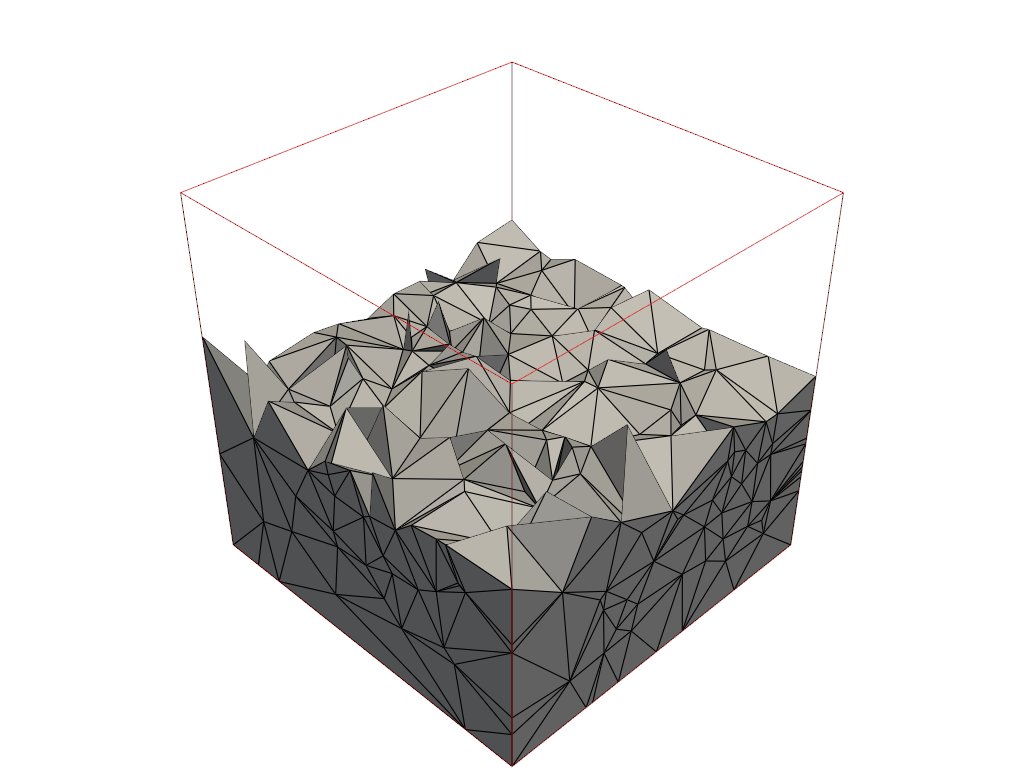

1000


In [4]:
RandomSample = np.random.rand(numVertices - 8,3)
RandomSample = add_box(RandomSample, tolerance)

randomDelaunay = Delaunay(RandomSample)

# Visualization of the Delaunay triangulation using PyVista
plot_pyvista(randomDelaunay.points , randomDelaunay.simplices)

print(len( randomDelaunay.points))

# Generate poisson disk mesh

Number of points:  1040


C:\Users\lenovo\AppData\Local\Temp\ipykernel_14604\3986142264.py:52: PyVistaDeprecationWarning: 
C:/Users/lenovo/AppData/Local/Temp/ipykernel_14604/3986142264.py:52: Argument 'color' must be passed as a keyword argument to function 'BasePlotter.add_mesh'.
From version 0.50, passing this as a positional argument will result in a TypeError.
  plotter.add_mesh(subgrid, 'lightgrey', lighting=True, show_edges=True)
C:\Users\lenovo\AppData\Local\Temp\ipykernel_14604\3986142264.py:53: PyVistaDeprecationWarning: 
C:/Users/lenovo/AppData/Local/Temp/ipykernel_14604/3986142264.py:53: Arguments 'color', 'style' must be passed as keyword arguments to function 'BasePlotter.add_mesh'.
From version 0.50, passing these as positional arguments will result in a TypeError.
  plotter.add_mesh(pv.Cube(center=(0.5, 0.5, 0.5)), 'r', 'wireframe')


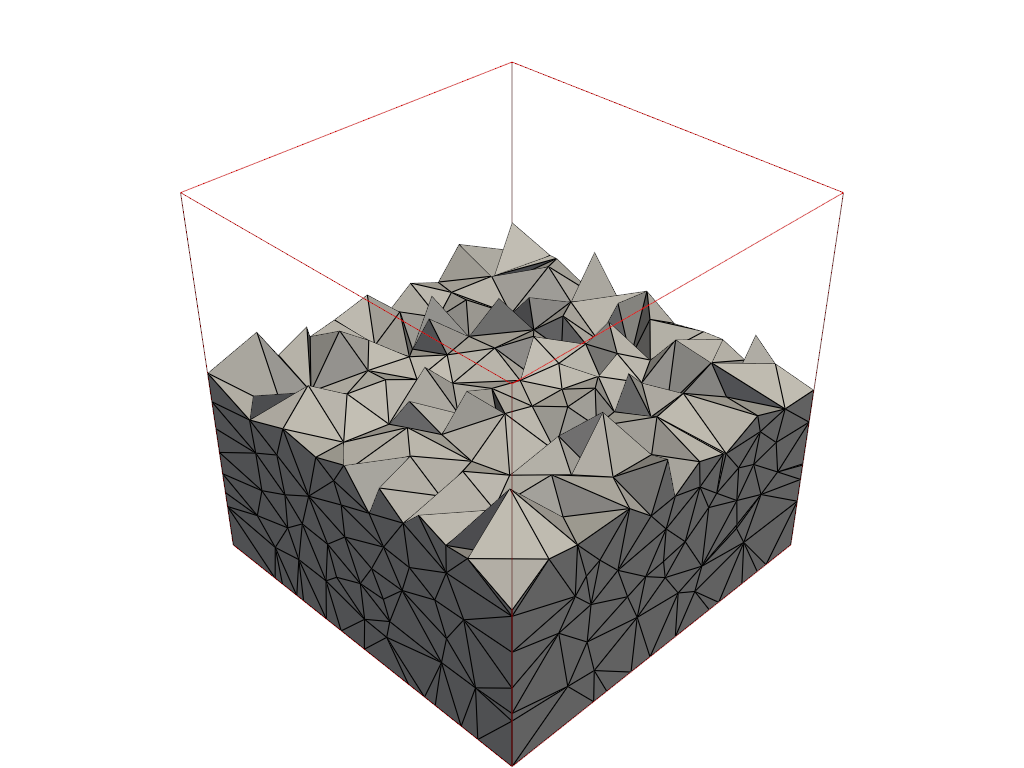

In [5]:
# To avoid agrupations being too dense

#radius= 0.0225 #50192

rng = np.random.default_rng()
engine = qmc.PoissonDisk(d=3, radius=radius, seed=rng)
sample = engine.fill_space()

sample = add_box(sample, tolerance)
poissonTriangulation = Delaunay(sample)

poissonPoints = sample
poissonTriangles = poissonTriangulation.simplices.copy()

print("Number of points: ", len(poissonPoints))
plot_pyvista(poissonPoints, poissonTriangulation.simplices)

## Generate semi-uniform Tetgen quality mesh

number of vertices:  413


C:\Users\lenovo\AppData\Local\Temp\ipykernel_14604\3986142264.py:52: PyVistaDeprecationWarning: 
C:/Users/lenovo/AppData/Local/Temp/ipykernel_14604/3986142264.py:52: Argument 'color' must be passed as a keyword argument to function 'BasePlotter.add_mesh'.
From version 0.50, passing this as a positional argument will result in a TypeError.
  plotter.add_mesh(subgrid, 'lightgrey', lighting=True, show_edges=True)
C:\Users\lenovo\AppData\Local\Temp\ipykernel_14604\3986142264.py:53: PyVistaDeprecationWarning: 
C:/Users/lenovo/AppData/Local/Temp/ipykernel_14604/3986142264.py:53: Arguments 'color', 'style' must be passed as keyword arguments to function 'BasePlotter.add_mesh'.
From version 0.50, passing these as positional arguments will result in a TypeError.
  plotter.add_mesh(pv.Cube(center=(0.5, 0.5, 0.5)), 'r', 'wireframe')


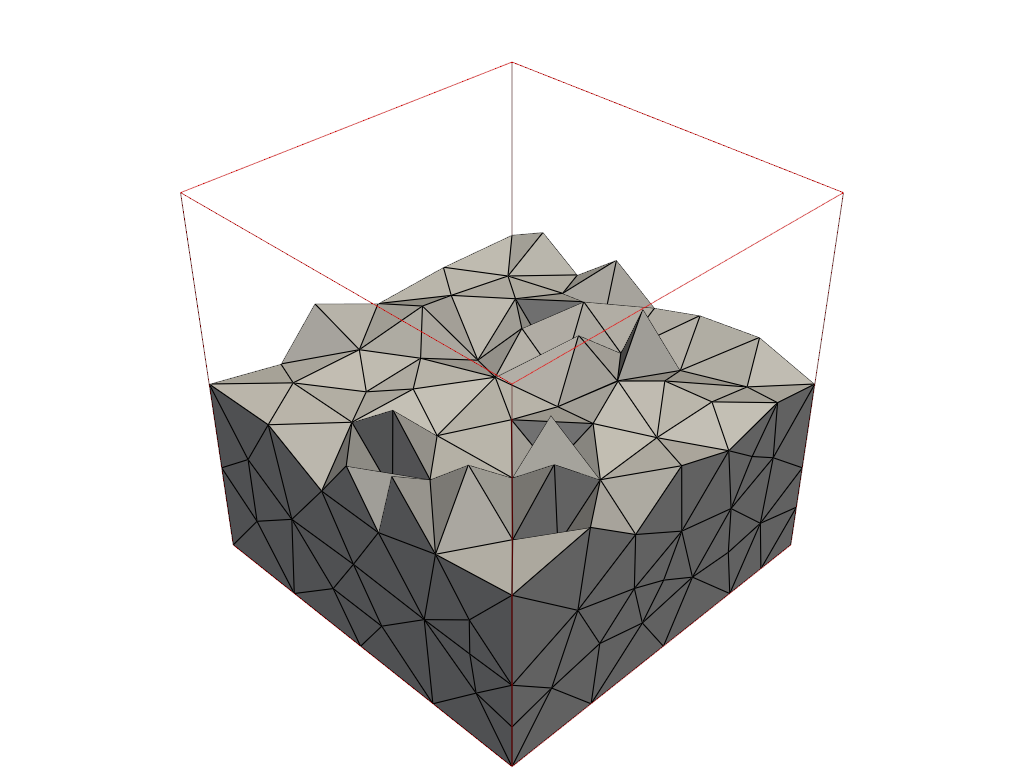

In [6]:

areaMax = "0.001" # 50027

v = np.array([[0, 0, 0], [1, 0, 0],
                  [1, 1, 0], [0, 1, 0],
                  [0, 0, 1], [1, 0, 1],
                  [1, 1, 1], [0, 1, 1],])
f = np.vstack([[0, 1, 2], [2, 3, 0],
                   [0, 1, 5], [5, 4, 0],
                   [1, 2, 6], [6, 5, 1],
                   [2, 3, 7], [7, 6, 2],
                   [3, 0, 4], [4, 7, 3],
                   [4, 5, 6], [6, 7, 4]])
tgen = tetgen.TetGen(v, f)
SemiUniformPoints, SemiUniformTriangles, _ , _ = tgen.tetrahedralize(switches="pqa" + areaMax)

print("number of vertices: ", len(SemiUniformPoints))

plot_pyvista(SemiUniformPoints, SemiUniformTriangles)


## Generate uniform grid mesh

In [7]:
#import numpy as np
#import pyvista as pv

#PointsperLine = lnspace  # The number of points per line

#PointsperLine = 5  # The number of points per line

# Generate points in 3D space

#points = np.array([[i / (PointsperLine - 1), j / (PointsperLine - 1), k / (PointsperLine - 1)]
#                   for k in range(PointsperLine)
#                   for j in range(PointsperLine)
#                   for i in range(PointsperLine)])

# Create a PyVista mesh object
#mesh = pv.PolyData(points)

# Perform a Delaunay 3D triangulation on the points

#tet_mesh = mesh.delaunay_3d(alpha=1.0)

# Extract the points and cells from the unstructured grid

#UniformPoints = tet_mesh.points
#uniformTriangles = tet_mesh.cells.reshape(-1, 5)[:, 1:]  # The first number in each row is the number of points in the cell (4 for tetrahedra)

# Now you have the vertices array and the cells array which contains the tetrahedra
# vertices - Nx3 array of the XYZ positions of the nodes
# cells - Mx4 array of the vertices that compose each tetrahedron

#plot_pyvista(UniformPoints, uniformTriangles)


C:\Users\lenovo\AppData\Local\Temp\ipykernel_14604\3986142264.py:52: PyVistaDeprecationWarning: 
C:/Users/lenovo/AppData/Local/Temp/ipykernel_14604/3986142264.py:52: Argument 'color' must be passed as a keyword argument to function 'BasePlotter.add_mesh'.
From version 0.50, passing this as a positional argument will result in a TypeError.
  plotter.add_mesh(subgrid, 'lightgrey', lighting=True, show_edges=True)
C:\Users\lenovo\AppData\Local\Temp\ipykernel_14604\3986142264.py:53: PyVistaDeprecationWarning: 
C:/Users/lenovo/AppData/Local/Temp/ipykernel_14604/3986142264.py:53: Arguments 'color', 'style' must be passed as keyword arguments to function 'BasePlotter.add_mesh'.
From version 0.50, passing these as positional arguments will result in a TypeError.
  plotter.add_mesh(pv.Cube(center=(0.5, 0.5, 0.5)), 'r', 'wireframe')


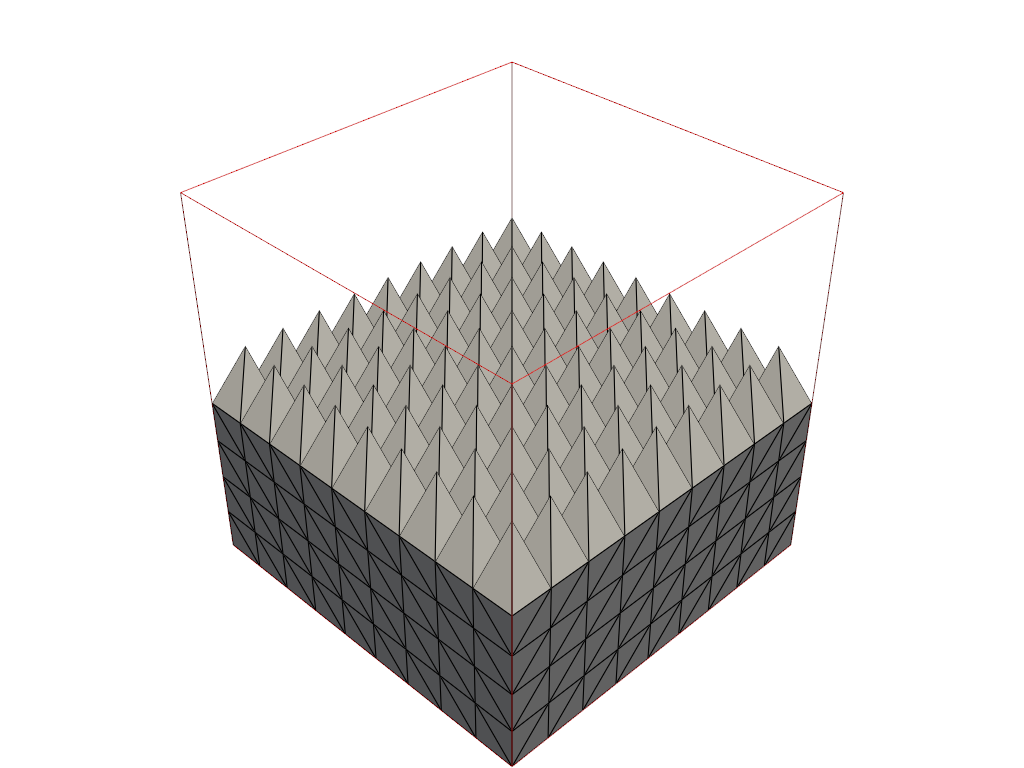

In [8]:
import pyvista as pv
import numpy as np
from vtk.util import numpy_support
from vtk import vtkTetra, vtkUnstructuredGrid, vtkCellArray

# Number of points per line
PointsperLine = lnspace  # Adjust this value as needed

# Generate points in 3D space within a unit cube
points = np.array([[i / (PointsperLine - 1), j / (PointsperLine - 1), k / (PointsperLine - 1)]
                   for k in range(PointsperLine)
                   for j in range(PointsperLine)
                   for i in range(PointsperLine)])

# Create a structured grid
grid = pv.StructuredGrid()
grid.points = points
grid.dimensions = (PointsperLine, PointsperLine, PointsperLine)

# Convert to an unstructured grid
unstructured_grid = grid.cast_to_unstructured_grid()

# Apply tetrahedralization
tetrahedralized = unstructured_grid.delaunay_3d(alpha=1.0)

# Extract nodes and tetrahedrons
UniformPoints = tetrahedralized.points
cells = tetrahedralized.cells

# Reshape cell array to extract only the indices of points in each tetrahedron
# Assuming each cell in the cell array is a tetrahedron
uniformTriangles = cells.reshape(-1, 5)[:, 1:]


# Now plot using the extracted nodes and simplices
plot_pyvista(UniformPoints, uniformTriangles)


# Generate mesh files

In [9]:
#Num of vertices and simplices
print(len(randomDelaunay.points), len(randomDelaunay.simplices))
print(len(poissonPoints), len(poissonTriangles))
print(len(SemiUniformPoints), len(SemiUniformTriangles))
print(len(UniformPoints), len(uniformTriangles))

# Create data folder if it doesn't exist (relative path from notebook)
PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "tetgen").is_dir():
    PROJECT_ROOT = PROJECT_ROOT.parent

folder = PROJECT_ROOT / "data" / "generated"
folder.mkdir(parents=True, exist_ok=True)

# Write .node files using meshio
meshio.write_points_cells(
    folder / f"{numVertices}random.node",
    randomDelaunay.points,
    [("tetra", randomDelaunay.simplices)]
)
meshio.write_points_cells(
    folder / f"{numVertices}poisson.node",
    poissonPoints,
    [("tetra", poissonTriangles)]
)
meshio.write_points_cells(
    folder / f"{numVertices}semiuniform.node",
    SemiUniformPoints,
    [("tetra", SemiUniformTriangles)]
)
meshio.write_points_cells(
    folder / f"{numVertices}uniform.node",
    UniformPoints,
    [("tetra", uniformTriangles)]
)

print(f"\nMesh files saved to: {folder}")

1000 4857
1040 4675
413 1725
1000 4374

Mesh files saved to: c:\dev\polylla3D\data\generated


## Call to tetgen

In [10]:
# Locate the executable produced by CMake (single- or multi-config build)
tetgen_candidates = [
    PROJECT_ROOT / "tetgen" / "build" / "Release" / "tetgen.exe",
    PROJECT_ROOT / "tetgen" / "build" / "tetgen.exe",
]
tetgen_exe = next(
    (path for path in tetgen_candidates if path.is_file()),
    None
)
if tetgen_exe is None:
    raise FileNotFoundError(
        "TetGen executable not found. Build it with CMake using "
        "-DBUILD_EXECUTABLE=ON, then run this cell again."
    )

# Create input folder if it doesn't exist
input_folder = PROJECT_ROOT / "data" / "input"
input_folder.mkdir(parents=True, exist_ok=True)

# Copy files from generated to input before running tetgen
from shutil import copy2

for mesh_type in ["random", "poisson", "semiuniform", "uniform"]:
    src = folder / f"{numVertices}{mesh_type}.node"
    dst = input_folder / f"{numVertices}{mesh_type}.node"
    if src.exists():
        copy2(src, dst)
        print(f"Copied {src.name} to {dst.parent.name}/")

tetgen_commands = [
    input_folder / f"{numVertices}random.node",
    input_folder / f"{numVertices}poisson.node",
    input_folder / f"{numVertices}semiuniform.node",
    input_folder / f"{numVertices}uniform.node",
]

# Execute tetgen for each file
for mesh_file in tetgen_commands:
    if mesh_file.exists():
        result = subprocess.run(
            [str(tetgen_exe), "-fzenn", str(mesh_file)],
            capture_output=True,
            text=True,
        )
        print(result.stdout, end="")
        if result.returncode != 0:
            print(result.stderr, end="")
            raise RuntimeError(f"TetGen failed with exit code {result.returncode}: {mesh_file}")
    else:
        print(f"Warning: {mesh_file.name} not found. Skipping...")

Copied 1000random.node to input/
Copied 1000poisson.node to input/
Copied 1000semiuniform.node to input/
Copied 1000uniform.node to input/
Opening c:\dev\polylla3D\data\input\1000random.node.
Delaunizing vertices...
Delaunay seconds:  0.009
Jettisoning redundant points.

Writing c:\dev\polylla3D\data\input\1000random.1.node.
Writing c:\dev\polylla3D\data\input\1000random.1.ele.
Writing c:\dev\polylla3D\data\input\1000random.1.face.
Writing c:\dev\polylla3D\data\input\1000random.1.t2f.
Writing c:\dev\polylla3D\data\input\1000random.1.edge.
Writing c:\dev\polylla3D\data\input\1000random.1.f2e.
Writing c:\dev\polylla3D\data\input\1000random.1.t2e.
Writing c:\dev\polylla3D\data\input\1000random.1.neigh.

Output seconds:  0.047
Total running seconds:  0.056

Statistics:

  Input points: 1000

  Mesh points: 992
  Mesh tetrahedra: 4857
  Mesh faces: 10191
  Mesh edges: 6325
  Convex hull faces: 954
  Convex hull edges: 1431

Opening c:\dev\polylla3D\data\input\1000poisson.node.
Delaunizing v